# Autoresearch-GLM Experiment Analysis

Analysis of autonomous feature-search results from `results.tsv`.


In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_auc, num_features, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_auc"] = pd.to_numeric(df["val_auc"], errors="coerce")
df["num_features"] = pd.to_numeric(df["num_features"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)


Total experiments: 30
Columns: ['commit', 'val_auc', 'num_features', 'status', 'description']


,commit,val_auc,num_features,status,description
0,66ca3da,0.762133,20,KEEP,baseline
1,9d655b6,0.762133,20,KEEP,collapse train.py to one explicit policy
2,4ebb883,0.768132,26,KEEP,try wider screen and larger interaction set
3,f0244d3,0.767909,26,DISCARD,try lighter tail clipping
4,68a5b15,0.768132,26,DISCARD,broaden interaction screening pool
5,75ee88a,0.768131,26,DISCARD,try light regularization on wider policy
6,5343b13,0.764793,23,DISCARD,try leaner feature and interaction caps
7,1877af1,0.766776,26,DISCARD,try univariate AUC variable screening
8,7ecef9d,0.768132,26,DISCARD,try a wider univariate screening set
9,fc20470,0.768071,30,DISCARD,try a larger transformed feature cap


In [104]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")
print(f"Crashes: {n_crash}")


Experiment outcomes:
status
DISCARD    19
KEEP       11

Keep rate: 11/30 = 36.7%
Crashes: 0


In [105]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    auc = row["val_auc"]
    desc = row["description"]
    print(f" #{i:3d} auc={auc:.6f} features={int(row['num_features'])} {desc}")


KEPT experiments (11 total):

 #  0 auc=0.762133 features=20 baseline
 #  1 auc=0.762133 features=20 collapse train.py to one explicit policy
 #  2 auc=0.768132 features=26 try wider screen and larger interaction set
 # 10 auc=0.768149 features=28 try a deeper interaction shortlist
 # 11 auc=0.768362 features=30 try an even deeper interaction shortlist
 # 12 auc=0.768365 features=34 try a larger feature cap with more interactions
 # 13 auc=0.769059 features=38 try a still larger transformed feature cap
 # 20 auc=0.770192 features=38 try slightly stronger clipping
 # 21 auc=0.770438 features=38 try stronger clipping again
 # 22 auc=0.770904 features=38 try clipping at the 96th percentile
 # 29 auc=0.770949 features=38 try light regularization with stronger clipping


## Val AUC Over Time

Track how the best kept validation AUC evolves as experiments progress. The running maximum shows the frontier, since higher is better.


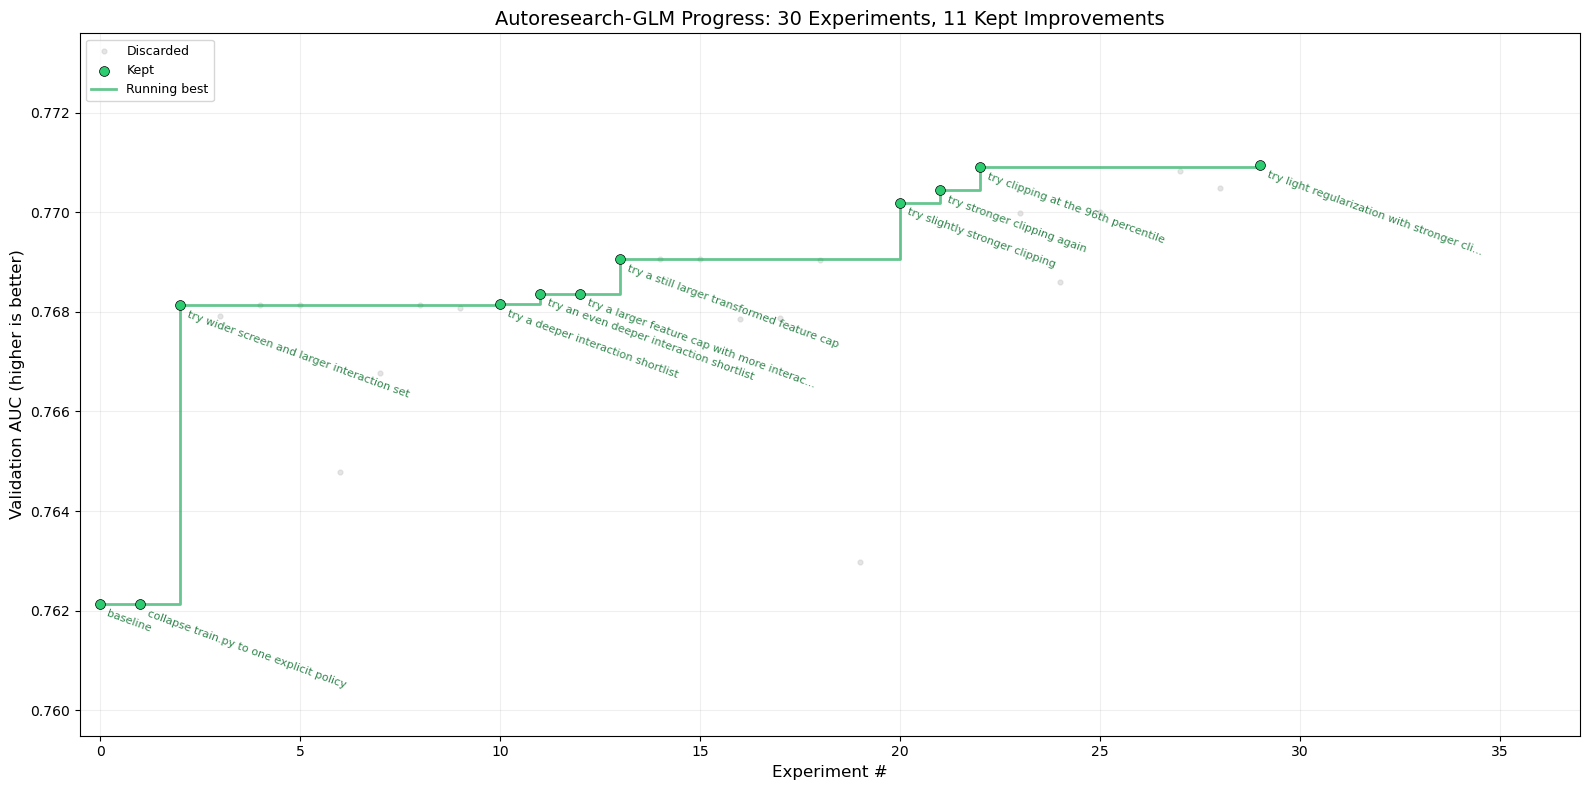

Saved to progress.png


In [106]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_auc = valid.loc[0, "val_auc"]

# Only plot points at or above baseline (the interesting region)
above = valid[valid["val_auc"] >= baseline_auc - 0.0005]

# Plot discarded as faint background dots
disc = above[above["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_auc"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = above[above["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_auc"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running maximum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_auc = valid.loc[kept_mask, "val_auc"]
running_best = kept_auc.cummax()
best = running_best.max()
ax.step(kept_idx, running_best, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, auc in zip(kept_idx, kept_auc):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, auc),
                textcoords="offset points",
                xytext=(4, -3), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=-20, ha="left", va="top")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation AUC (higher is better)", fontsize=12)
ax.set_title(f"Autoresearch-GLM Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.2)

# Add extra room on the right so the ending annotations do not get clipped.
ax.set_xlim(-0.5, valid.index.max() + 8.0)

# Y-axis: from just below baseline to just above best
margin = (best - baseline_auc) * 0.3
margin = max(margin, 0.0004)
ax.set_ylim(baseline_auc - margin, best + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics


In [107]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_auc = df.iloc[0]["val_auc"]
best_auc = kept["val_auc"].max()
best_row = kept.loc[kept["val_auc"].idxmax()]

print(f"Baseline val_auc: {baseline_auc:.6f}")
print(f"Best val_auc: {best_auc:.6f}")
print(f"Total improvement: {best_auc - baseline_auc:.6f} ({(best_auc - baseline_auc) / baseline_auc * 100:.2f}%)")
print(f"Best experiment: {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f" Experiment #{row['index']:3d}: auc={row['val_auc']:.6f} {desc}")


Baseline val_auc: 0.762133
Best val_auc: 0.770949
Total improvement: 0.008816 (1.16%)
Best experiment: try light regularization with stronger clipping

Cumulative effort per improvement:
 Experiment #  0: auc=0.762133 baseline
 Experiment #  1: auc=0.762133 collapse train.py to one explicit policy
 Experiment #  2: auc=0.768132 try wider screen and larger interaction set
 Experiment # 10: auc=0.768149 try a deeper interaction shortlist
 Experiment # 11: auc=0.768362 try an even deeper interaction shortlist
 Experiment # 12: auc=0.768365 try a larger feature cap with more interactions
 Experiment # 13: auc=0.769059 try a still larger transformed feature cap
 Experiment # 20: auc=0.770192 try slightly stronger clipping
 Experiment # 21: auc=0.770438 try stronger clipping again
 Experiment # 22: auc=0.770904 try clipping at the 96th percentile
 Experiment # 29: auc=0.770949 try light regularization with stronger clipping


## Top Hits (Kept Experiments by Improvement)


In [108]:
# Each kept experiment's delta is measured vs the previous kept experiment's auc
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_auc"] = kept["val_auc"].shift(1)
kept["delta"] = kept["val_auc"] - kept["prev_auc"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4} {'Delta':>8} {'AUC':>10} Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d} {row['delta']:+.6f} {row['val_auc']:.6f} {row['description']}")

print(f"\n{'':>4} {hits['delta'].sum():+.6f} {'':>10} TOTAL improvement over baseline")


Rank    Delta        AUC Description
--------------------------------------------------------------------------------
   1 +0.005999 0.768132 try wider screen and larger interaction set
   2 +0.001133 0.770192 try slightly stronger clipping
   3 +0.000694 0.769059 try a still larger transformed feature cap
   4 +0.000466 0.770904 try clipping at the 96th percentile
   5 +0.000246 0.770438 try stronger clipping again
   6 +0.000213 0.768362 try an even deeper interaction shortlist
   7 +0.000045 0.770949 try light regularization with stronger clipping
   8 +0.000017 0.768149 try a deeper interaction shortlist
   9 +0.000003 0.768365 try a larger feature cap with more interactions
  10 +0.000000 0.762133 collapse train.py to one explicit policy

     +0.008816            TOTAL improvement over baseline
